<a href="https://colab.research.google.com/github/siinwook/PCA-from-Scratch/blob/main/pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**PCA**

In [140]:
import numpy as np
import matplotlib.pyplot as plt

##MNIST

In [141]:
import torch
import torchvision
from torchvision.transforms import v2

train_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float64, scale=True)
  ])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train = True,
    transform=train_transform,
    download=True,

)

##Data Flatten

In [142]:
data = (train_dataset.data / 255.0).numpy()
print(data.shape)

N = data.shape[0]
data = data.reshape((N,-1))
print(data.shape)

(60000, 28, 28)
(60000, 784)


##PCA with Reduced-SVD





In [143]:
mean = data.mean(axis=0,keepdims=True)
data_centered = data - mean

U, S, Vt = np.linalg.svd(data_centered,full_matrices=False)

In [144]:
to_dim = 10 # Number of principal components
V = Vt.transpose(1,0)

Z = data_centered @ V[:,:to_dim] # (N,784) -> (N,10)

data_reconstructed = Z @ Vt[:to_dim,:] + mean # (N,10) -> (N,784)

##Ten Basis Images (Order of Principal Components)

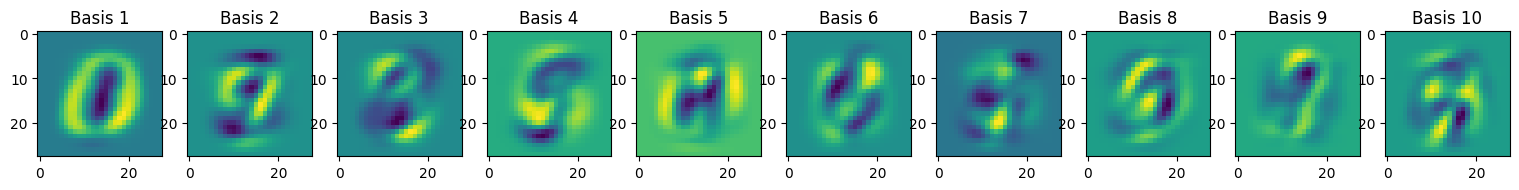

In [146]:
plt.figure(figsize=(19,6))

for i in range(to_dim):
  plt.subplot(1,to_dim,i+1)
  plt.imshow(Vt[i].reshape(28,28))
  plt.title(f"Basis {i+1}")

plt.show()

Observation:
- Each component captures the direction of pixel variation.
- First component represents whether shape is round or straight
- Second and third component represent whether shape resembles the specific number(*'9'*, and *'3'*)

Interpretation:
- PCA captures the largest global variations in pixel space.
- The largest variation of MNIST is roundness or straightness.

##Weight Sum of Basis Images

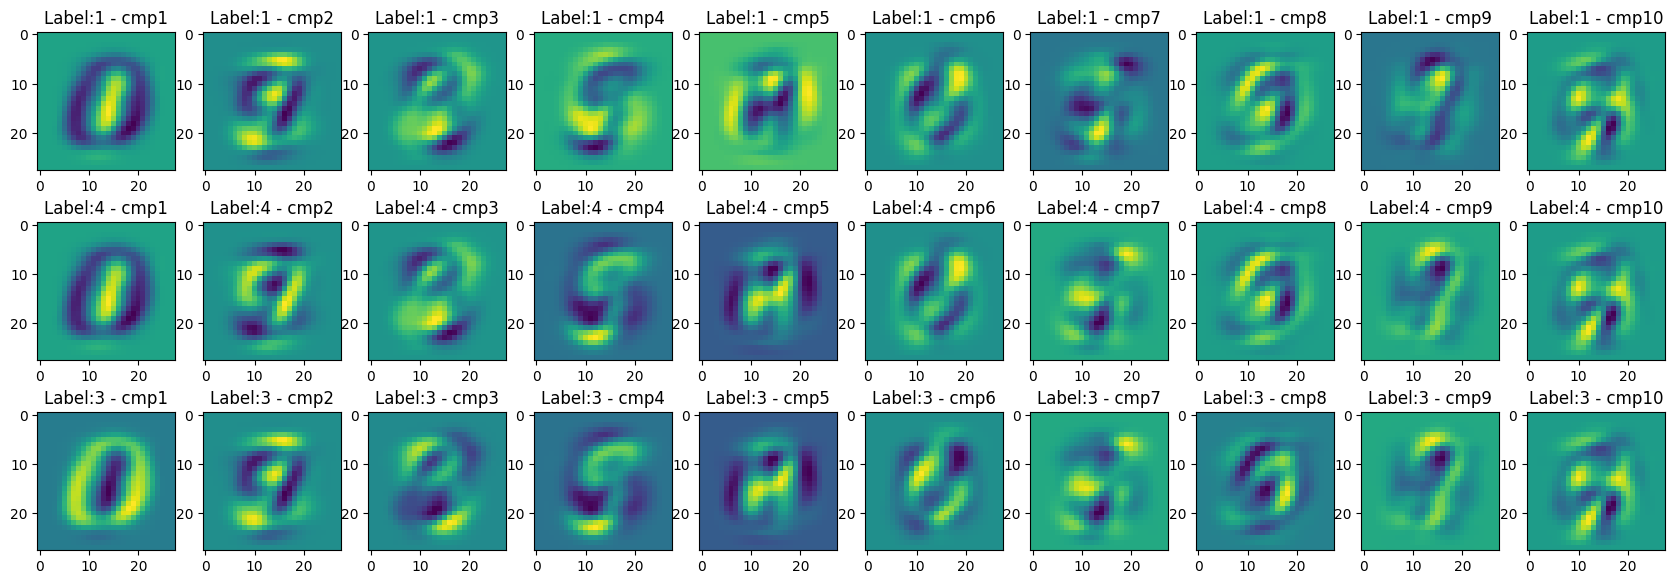

In [151]:
idxs = np.array([59498,10679,35143]) # Index of label [1,9,3]
label = np.array([1,4,3])
img_comps = [[],[],[]]

plt.figure(figsize=(21,7))
for i in range(len(idxs)):
  idx = idxs[i]
  z = Z[idx:idx+1,:]
  for j in range(to_dim):
    plt.subplot(len(idxs),to_dim,i * to_dim + j + 1)
    img_comp = z[:,j] @ Vt[j:j+1,:]
    img_comps[i].append(img_comp)

    plt.imshow(img_comp.reshape(28,28))
    plt.title(f"Label:{label[i]} - cmp{j+1}")
plt.show()

Observation:
- 1-labeled and 4-labeled have similar direction in first and third component, while 1-labeled and 3-labeled have similar direction in second component

Interpretation:
- 1-labeled has 'straight bar' direction in first component, and it fits common sense
- 4-labeled has  'shape of number 9' direction in second component. Considering number 4 resembles to number 9, it is acceptable.
- 3-labeled has 'shape of number 3' direction in third component, as we expected.

##Reconstruction Procedure

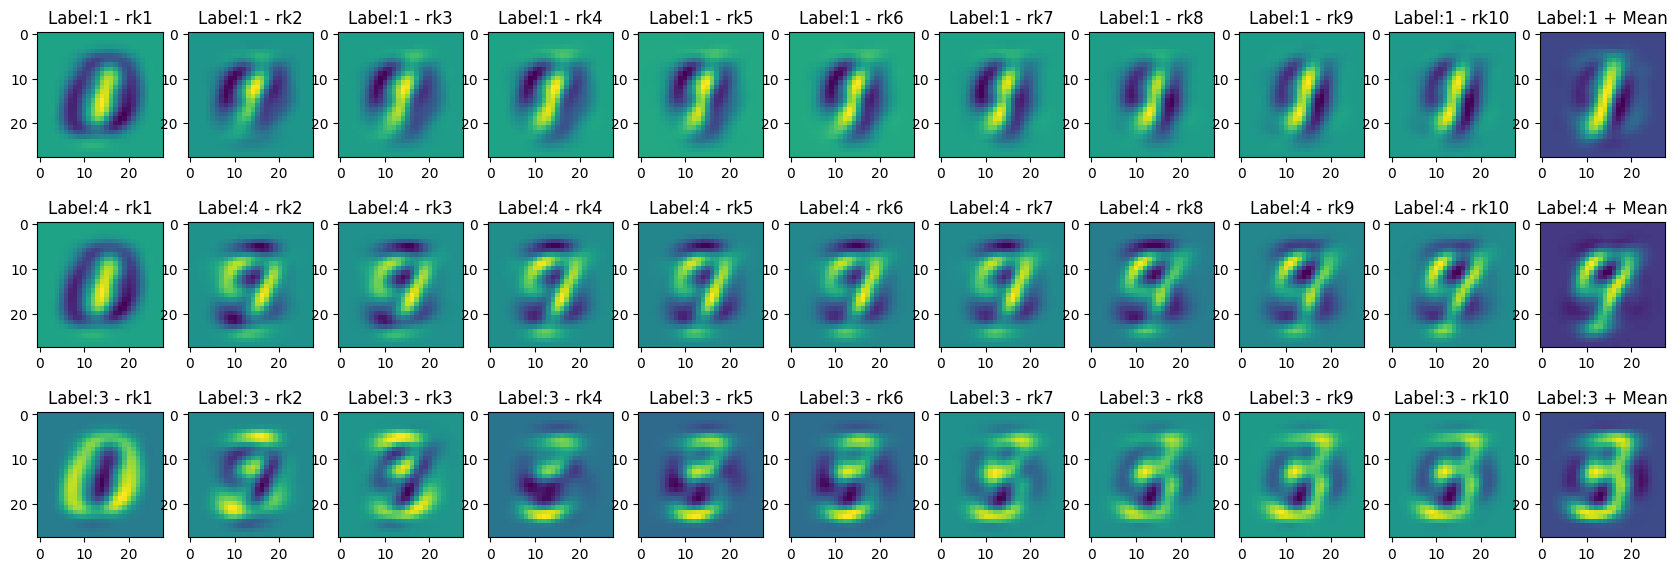

35143


In [148]:
img_comps = np.array(img_comps)

plt.figure(figsize=(21,7))
for i in range(len(idxs)):
  img_reconstructed = np.zeros((784))
  for j in range(to_dim):
    plt.subplot(len(idxs),to_dim+1,i*(to_dim+1)+j+1)
    img_reconstructed += img_comps[i,j] # Sum of Rank-1 Matrices
    plt.imshow(img_reconstructed.reshape(28,28))
    plt.title(f"Label:{label[i]} - rk{j+1}")
  plt.subplot(len(idxs),to_dim+1,i*(to_dim+1)+11)
  plt.imshow((img_reconstructed+mean.squeeze()).reshape(28,28))
  plt.title(f"Label:{label[i]} + Mean")

plt.show()
print(idx)

Observation:
- 1-labeled data reconstructs its overall shape in first component.
- 4-labeled data reconstructs its overall shape in second component.
- 3-labeled data reconstructs its overall shape in third component.

Interpretation:
- MNIST dataset can recover its original information only with few principal components.

##Reconstruction with Only Principal Components

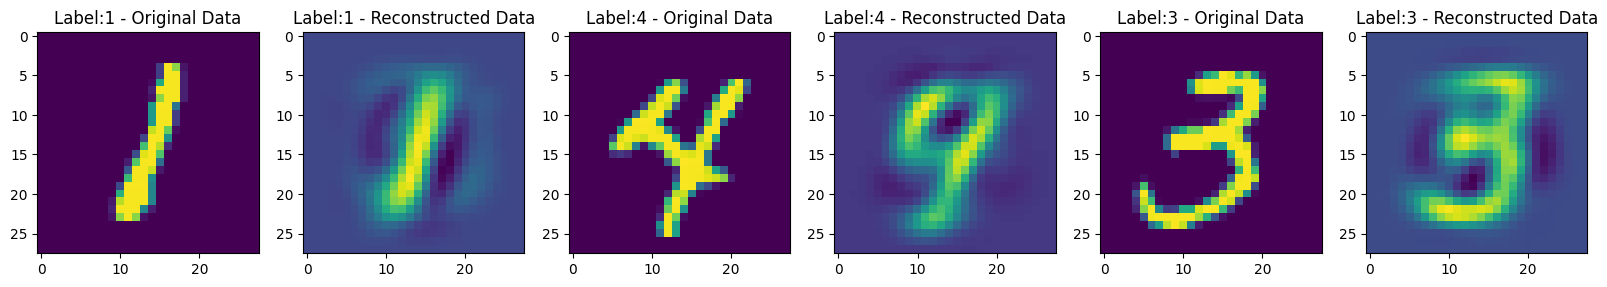

In [150]:
plt.figure(figsize=(20,6))

plt.subplot(1,6,1)
plt.imshow((data[idxs[0]]).reshape(28,28))
plt.title('Label:1 - Original Data')

plt.subplot(1,6,2)
plt.imshow(data_reconstructed[idxs[0]].reshape(28,28))
plt.title('Label:1 - Reconstructed Data')

plt.subplot(1,6,3)
plt.imshow((data[idxs[1]]).reshape(28,28))
plt.title('Label:4 - Original Data')

plt.subplot(1,6,4)
plt.imshow(data_reconstructed[idxs[1]].reshape(28,28))
plt.title('Label:4 - Reconstructed Data')

plt.subplot(1,6,5)
plt.imshow((data[idxs[2]]).reshape(28,28))
plt.title('Label:3 - Original Data')

plt.subplot(1,6,6)
plt.imshow(data_reconstructed[idxs[2]].reshape(28,28))
plt.title('Label:3 - Reconstructed Data')

plt.show()

Observation:
- One can easily agree with that reconstructed data almost resembles to original data.

Interpretation:
- Even after dimension reduction(784 to 10) data captures global large variations and  preserves its overall information.

##Explained Variance Ratio

In [ ]:
print(f"explained variance ratio: {np.sum(S[:to_dim]**2) / np.sum(S**2)}")

explained variance ratio: 0.48814985156059265


Interpretation:
- Approximately 50% of variance can be explained even with only 1.2% of original dimension